# **Project Idea (Part A)**

### The safety of a car is one of the key considerations when evaluating and purchasing a car. With the negative perception of drivers in the DMV area, 

# **Dataset Curation and Preprocessing (Part B)**

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import json
from scipy import stats
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

In [39]:
## Loading and Exploring the Data
col_datatypes = {
    "Report Number": str,
    "Local Case Number": str, 
    "Agency Name": str,
    "ACRS Report Type": str,
    "Crash Date/Time": str, 
    "Route Type": str, 
    "Road Name": str, 
    "Cross-Street Name": str, 
    "Off-Road Description": str, 
    "Municipality": str, 
    "Related Non-Motorist": str, 
    "Collision Type": str,
    "Weather": str,
    "Surface Condition": str,
    "Light": str,
    "Traffic Control": str,
    "Driver Substance Abuse": str,
    "Non-Motorist Substance Abuse": str,
    "Person ID": str,
    "Driver At Fault": str,
    "Injury Severity": str,
    "Circumstance": str,
    "Driver Distracted By": str,
    "Drivers License State": str,
    "Vehicle ID": str,
    "Vehicle Damage Extent": str,
    "Vehicle First Impact Location": str,
    "Vehicle Body Type": str,
    "Vehicle Movement": str,
    "Vehicle Going Dir": str,
    "Speed Limit": int,
    "Driverless Vehicle": str,
    "Parked Vehicle": str,
    "Vehicle Year": int,
    "Vehicle Make": str,
    "Vehicle Model": str,
    "Latitude": float,
    "Longitude": float,
    "Location": str
}

crash_df = pd.read_csv("Crash_Reporting_-_Drivers_Data.csv", dtype=col_datatypes)
print(f"Total Data Entries: {crash_df.shape[0]}")
print(f"Number of Features: {crash_df.shape[1]}")
print(f"Number of Numerical Features: {len(crash_df.select_dtypes(include=['int64', 'float64']).columns)}\n   \-> {list(crash_df.select_dtypes(include=['int64', 'float64']).columns)}")
print(f"Number of Categorical Features: {len(crash_df.select_dtypes(include=['str']).columns)}\n   \-> {list(crash_df.select_dtypes(include=['str']).columns)}")
display(crash_df.head())

Total Data Entries: 210736
Number of Features: 39
Number of Numerical Features: 4
   \-> ['Speed Limit', 'Vehicle Year', 'Latitude', 'Longitude']
Number of Categorical Features: 35
   \-> ['Report Number', 'Local Case Number', 'Agency Name', 'ACRS Report Type', 'Crash Date/Time', 'Route Type', 'Road Name', 'Cross-Street Name', 'Off-Road Description', 'Municipality', 'Related Non-Motorist', 'Collision Type', 'Weather', 'Surface Condition', 'Light', 'Traffic Control', 'Driver Substance Abuse', 'Non-Motorist Substance Abuse', 'Person ID', 'Driver At Fault', 'Injury Severity', 'Circumstance', 'Driver Distracted By', 'Drivers License State', 'Vehicle ID', 'Vehicle Damage Extent', 'Vehicle First Impact Location', 'Vehicle Body Type', 'Vehicle Movement', 'Vehicle Going Dir', 'Driverless Vehicle', 'Parked Vehicle', 'Vehicle Make', 'Vehicle Model', 'Location']


,Report Number,Local Case Number,Agency Name,ACRS Report Type,Crash Date/Time,Route Type,Road Name,Cross-Street Name,Off-Road Description,Municipality,...,Vehicle Going Dir,Speed Limit,Driverless Vehicle,Parked Vehicle,Vehicle Year,Vehicle Make,Vehicle Model,Latitude,Longitude,Location
0,MCP3126006X,250037402,MONTGOMERY,Injury Crash,08/21/2025 05:21:00 PM,Maryland (State) Route,NaN,NaN,NaN,NaN,...,Northbound,40,No,No,2013,KIA,SOUL,39.219796,-77.257416,"(39.219796, -77.25741635)"
1,MCP2349001B,250037516,MONTGOMERY,Property Damage Crash,08/22/2025 10:44:00 AM,Interstate (State),EISENHOWER MEMORIAL HWY,NaN,NaN,NaN,...,Northbound,55,No,No,0,NaN,NaN,39.180181,-77.250657,"(39.18018079, -77.25065714)"
2,MCP296500BC,250033157,MONTGOMERY,Property Damage Crash,07/25/2025 11:55:00 AM,Bicycle Route,NaN,NEW HAMPSHIRE AVE (SB/L) NORBECK RD (WB/L) SPE...,NaN,NaN,...,Westbound,40,No,No,2023,LEXUS,RX,39.121219,-76.988905,"(39.12121898, -76.98890509)"
3,MCP2159003K,250037509,MONTGOMERY,Property Damage Crash,08/22/2025 10:36:00 AM,Maryland (State) Route,NaN,NaN,NaN,NaN,...,Southbound,30,No,No,2003,TOYOTA,SIENNA,39.207931,-77.141480,"(39.20793083, -77.1414795)"
4,MCP312900D6,250034573,MONTGOMERY,Property Damage Crash,08/03/2025 02:10:00 PM,NaN,NaN,NaN,Parking Lot Way PARKING LOT OF 2741 UNI...,NaN,...,Not On Roadway,0,No,No,2023,SUBARU,IMPREZA,39.039662,-77.057238,"(39.03966248, -77.05723843)"


 #### From this data preview, we can see that this dataset has 39 features. Of these 39 features, 35 of them are categorical and the other 4 are numerical features. In addition, we have 210,736 entries in this dataset. With the preview alone, we can see that there exist many missing values that will mess up our data analysis and predictions. A good first step would be to handle these badly collected entries.

 ### Data Source:
 #### Montgomery County. (n.d.). Crash Reporting - Incidents data [Dataset].https://data.montgomerycountymd.gov/Public-Safety/Crash-Reporting-Incidents-Data/bhju-22kf/about_data

_______________________________________________________________________________________________________________________________________________________

# **Data Exploration and Summary Statistics (Part C)**

### **Check how unique values vs total values:**


In [40]:
total_entries = crash_df.shape[0]
unique_df = pd.DataFrame()
unique_df["Column Name"] = crash_df.columns
unique_df["Unique Values"] = unique_df["Column Name"].apply(lambda x: crash_df[x].nunique())
unique_df["Total Values"] = unique_df["Column Name"].apply(lambda x: total_entries - crash_df[x].isna().sum())
unique_df["Is Unique"] = unique_df["Unique Values"] == unique_df["Total Values"]
unique_df

,Column Name,Unique Values,Total Values,Is Unique
0,Report Number,118843,210736,False
1,Local Case Number,118729,210736,False
2,Agency Name,10,210736,False
3,ACRS Report Type,3,210736,False
4,Crash Date/Time,115943,210736,False
5,Route Type,19,190097,False
6,Road Name,4789,186385,False
7,Cross-Street Name,7536,170288,False
8,Off-Road Description,13978,19597,False
9,Municipality,20,19126,False


### **Let's Graph it!**

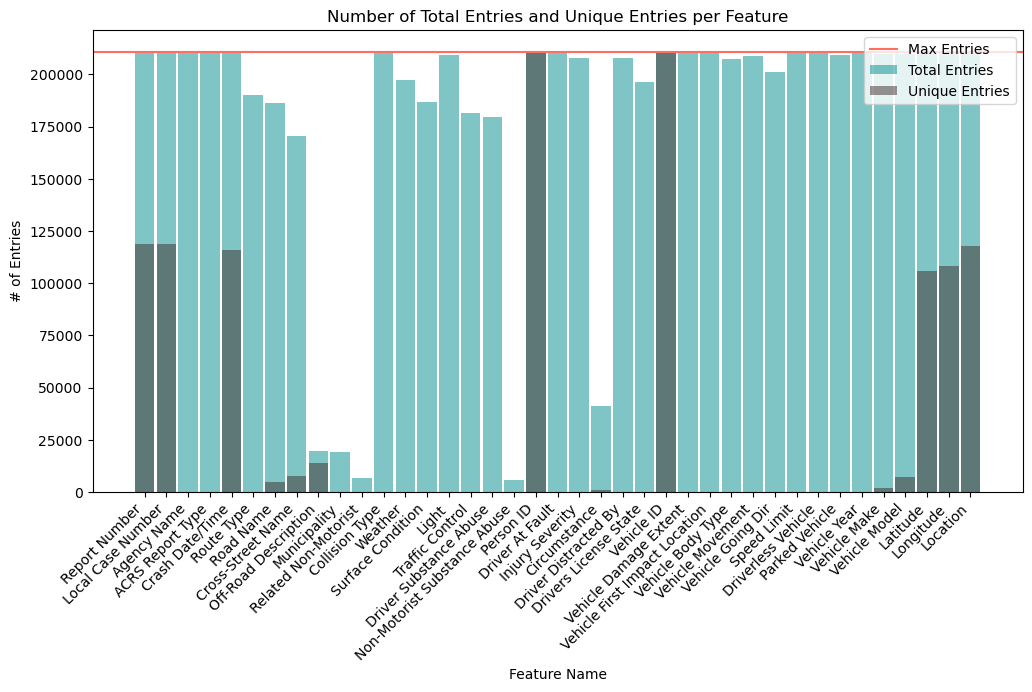

In [41]:
plt.figure(figsize=(12, 6))
plt.bar(unique_df["Column Name"], unique_df["Total Values"], alpha=0.5, width=0.9, label="Total Entries", color="#008C8C")
plt.bar(unique_df["Column Name"], unique_df["Unique Values"], alpha=0.5, width=0.9, label="Unique Entries", color="#3E2A2A")
plt.axhline(total_entries, color='#FF6F61', label='Max Entries')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Feature Name")
plt.ylabel("# of Entries")
plt.title("Number of Total Entries and Unique Entries per Feature")
plt.legend(loc="upper right")
plt.show()

_______________________________________________________________________________________________________________________________________________________

# **MISSING**

### **Understanding the missing values in our data**

In [42]:
na_dict = {}
print("==============[ N/A Statistics ]==============")
print(f"Out of {crash_df.shape[0]} entries, the following number of entries have no values for the columns]\n")
print(f"Total Entries: {crash_df.shape[0]}")
na_dict = crash_df.isna().sum().astype(int).to_dict()
sorted_na = dict(sorted(na_dict.items(), key=lambda x: x[1], reverse=True))
print(json.dumps(sorted_na, indent=2))

==============[ N/A Statistics ]==============
Out of 210736 entries, the following number of entries have no values for the columns]

Total Entries: 210736
{
  "Non-Motorist Substance Abuse": 205003,
  "Related Non-Motorist": 203857,
  "Municipality": 191610,
  "Off-Road Description": 191139,
  "Circumstance": 169751,
  "Cross-Street Name": 40448,
  "Driver Substance Abuse": 31320,
  "Traffic Control": 29088,
  "Road Name": 24351,
  "Surface Condition": 23976,
  "Route Type": 20639,
  "Drivers License State": 14350,
  "Weather": 13356,
  "Vehicle Going Dir": 9525,
  "Vehicle Body Type": 3212,
  "Driver Distracted By": 2856,
  "Injury Severity": 2665,
  "Vehicle Movement": 1679,
  "Parked Vehicle": 1526,
  "Light": 1445,
  "Vehicle Model": 1174,
  "Vehicle Make": 1132,
  "Collision Type": 585,
  "Vehicle Damage Extent": 316,
  "Vehicle First Impact Location": 156,
  "Report Number": 0,
  "Local Case Number": 0,
  "Agency Name": 0,
  "ACRS Report Type": 0,
  "Crash Date/Time": 0,
  "Per

#### From the previous results, we can see that the columns `"Non-Motorist Substance Abuse"`, `"Related Non-Motorists"`, `"Municipality"`, `"Off-Road Description"`, `"Circumstance"`, `"Cross-Street Name"`, `"Driver Substance Abuse"`, and `"Traffic Control"` have over 25,000 missing values in the dataset. We can conclude that these columns should be reconsidered in our EDA as their omission would allow us to consider more datapoints. 

### **Let's remove these features!**

In [43]:
sparse_cols = []
for key in sorted_na:
    if sorted_na[key] > 25000:
        sparse_cols.append(key)
if sparse_cols[0] in crash_df.columns:
    crash_df = crash_df.drop(columns=sparse_cols)
print(f"Number of features: {crash_df.shape[1]-2}")

Number of features: 29


### **Now that we've filtered the features, lets drop any entries with N/A values**

In [44]:
crash_df = crash_df.dropna()
print(f"Number of features: {crash_df.shape[1]-2} and Number of entries: {crash_df.shape[0]}")
display(crash_df.head(7))


Number of features: 29 and Number of entries: 152393


,Report Number,Local Case Number,Agency Name,ACRS Report Type,Crash Date/Time,Route Type,Road Name,Collision Type,Weather,Surface Condition,...,Vehicle Going Dir,Speed Limit,Driverless Vehicle,Parked Vehicle,Vehicle Year,Vehicle Make,Vehicle Model,Latitude,Longitude,Location
5,MCP284600BN,250037004,MONTGOMERY,Injury Crash,08/19/2025 09:50:00 AM,County Route,GRAND PRE RD,Single Vehicle,Rain,Wet,...,Northbound,25,No,No,2016,MAZDA,CX-5,39.092734,-77.076470,"(39.09273383, -77.07647)"
9,MCP137801DC,250034694,MONTGOMERY,Property Damage Crash,08/04/2025 03:47:00 PM,Maryland (State) Route,GEORGIA AVE (SB/L),Front to Rear,Clear,Dry,...,Eastbound,35,No,No,2018,FORD,TRANSIT CONNECT,39.153220,-77.067015,"(39.15322038, -77.06701504)"
11,MCP3381002W,250037120,MONTGOMERY,Property Damage Crash,08/19/2025 08:35:00 PM,County Route,WISTERIA DR,Front to Rear,Clear,Dry,...,Southbound,40,No,No,2016,GILLIG,LOW FLOOR BUS,39.176935,-77.270199,"(39.17693504, -77.27019937)"
13,MCP2583004W,250037308,MONTGOMERY,Injury Crash,08/21/2025 02:15:00 AM,County Route,SHADY GROVE RD (SB/L),"Sideswipe, Same Direction",Clear,Dry,...,Westbound,40,No,No,2016,GILLIG,LOW FLOOR BUS,39.129422,-77.165412,"(39.12942178, -77.16541241)"
14,MCP2723009V,250037762,MONTGOMERY,Injury Crash,08/23/2025 06:20:00 PM,County Route,PEBBLESTONE DR,Front to Front,Clear,Dry,...,Eastbound,30,No,No,2015,JEEP,CHEROKEE,39.090965,-77.019478,"(39.09096543, -77.01947815)"
15,MCP2349001B,250037516,MONTGOMERY,Property Damage Crash,08/22/2025 10:44:00 AM,Interstate (State),EISENHOWER MEMORIAL HWY,Single Vehicle,Clear,Dry,...,Northbound,55,No,No,2017,CHEVROLET,MALIBU,39.180181,-77.250657,"(39.18018079, -77.25065714)"
18,DM8386002B,250037144,TAKOMA,Property Damage Crash,08/20/2025 03:15:00 AM,Municipality Route,SYCAMORE AVE,Front to Rear,Rain,Wet,...,Westbound,25,No,No,2021,HONDA,CR-V,38.978059,-77.005619,"(38.97805945, -77.00561883)"


_______________________________________________________________________________________________________________________________________________________

# **OUTLIERS**

### After analyzing the number of missing values in our datatset, we should try to eliminate entries that contain outliers in any of our numerical categories. Taking a look at these categories, we can see that speed limit cannot contain outliers because its a numerical representation of categorical data and our position data cannot contain outliers because they're valid longitude and latitude values within Maryland. This leaves us with `Vehicle Year` to eliminate outliers from. 
  
## Let's start with that:

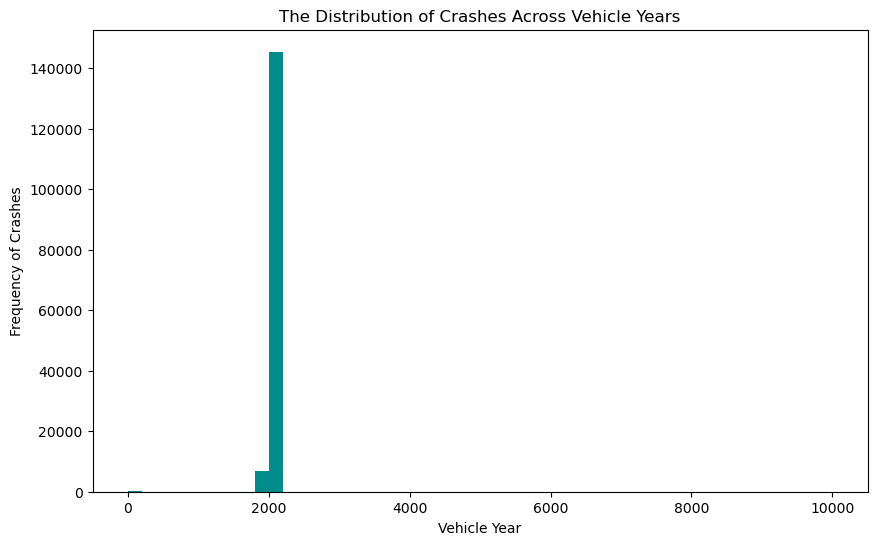

In [45]:
## Plot the current distribution of datapoints
plt.figure(figsize=(10, 6))
plt.hist(crash_df["Vehicle Year"], bins=50, color="#008C8C")
plt.xlabel("Vehicle Year")
plt.ylabel("Frequency of Crashes")
plt.title("The Distribution of Crashes Across Vehicle Years")
plt.show()

### Hmm... Something seems to be wrong with the distribution of values for `Vehicle Years`. The first problematic observation that can be made is the hump in the 0 bin. This, for obvious reasons, doesn't make sense for vehicle car years. In addition, we can see that the graph has auto-distributed across a range of `(0,10000)`. This tells us that there must be some low-frequency outliers towards the 10,000 mark that's spreading the graph thin.

### **Let's explore this in further detail:**

In [46]:
desc_stats = crash_df["Vehicle Year"].describe()
IQR = desc_stats["75%"] - desc_stats["25%"]
lower_bound = int(desc_stats["25%"] - (1.5*IQR))
upper_bound = int(desc_stats["75%"] + (1.5*IQR))
print(f"IQR:{IQR}")
print(f"We declare points outside of the range {lower_bound} <= x <= {upper_bound} an outlier")
print("This makes the following unique values outliers:")
vehicle_years = crash_df[(crash_df["Vehicle Year"]>upper_bound) | (crash_df["Vehicle Year"]<lower_bound)]["Vehicle Year"].unique()
print(vehicle_years)

IQR:9.0
We declare points outside of the range 1993 <= x <= 2029 an outlier
This makes the following unique values outliers:
[1111 1992 1990 1988 1987 1977 9999 1989 1991 1984    0 1900 1981 2915
 1983 1966   99 2033  200 1967    3 1975 1980 1978 1969  201 2918  215
 1986 2996 1965 1982 2917 2103 2040 1985 1968 1972 1960 1970   15 1938
 1979 2991 1949 1901 2997  202 1976   97 1971 3013 2914 5005 2911 2201
 1140 1961 1005 1947 2099 1014 2100 1955 2208 1974 2200 1930    8 1963
 2048 2104 1015  198 2919 2055 3003   13 8008 2204 3863 2912    2 1008
   14 1959 1025 2998    4 1234 9000 3012 2109 1957]


### Looking at the data, we can compute an `IQR` of 10 (2016 - 2006). This gives us a `lower_bound` and `upper_bound` of 1991 and 2031 respectively. When we calculate the possible outlier points, however, we allow implausible values to persist in our data. To ellaborate, an `upper_bound` of 2031 doesn't make sense to describe this feature, since the maximum possible value for `Vehicle Year` is 2027. For these reasons we might want to implement a manual cap for the upper bounds and keep the lower bounds the same.

### **How about we implement a hardcap for the upperbounds?**

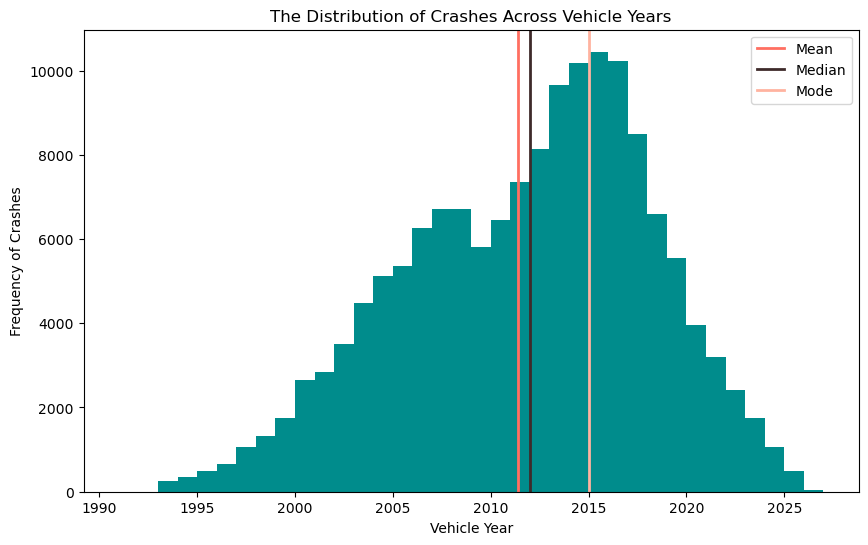

In [47]:
filtered_values = crash_df[(crash_df["Vehicle Year"]<=2027) & (crash_df["Vehicle Year"]>=lower_bound)]["Vehicle Year"]
#print(sorted(filtered_values.unique()))
plt.figure(figsize=(10, 6))
plt.hist(filtered_values, bins=36, range=(1991,2027), color="#008C8C")
plt.axvline(filtered_values.mean(), label="Mean", color="#FF6F61", lw=2.0)
plt.axvline(filtered_values.median(), label="Median", color="#3E2A2A", lw=2.0)
plt.axvline(filtered_values.mode()[0], label="Mode", color="#FFB3A0", lw=2.0)
plt.xlabel("Vehicle Year")
plt.ylabel("Frequency of Crashes")
plt.title("The Distribution of Crashes Across Vehicle Years")
plt.legend()
plt.show()

### With this showing promising results, lets drop any rows that fall outsides of the lower, upper range

In [48]:
out_of_bounds_idx = crash_df[(crash_df["Vehicle Year"]>2027) | (crash_df["Vehicle Year"]<lower_bound)].index
crash_df.drop(index=out_of_bounds_idx,axis=0,inplace=True)
print(f"Entries Left: {crash_df.shape[0]}, Entries Deleted: {total_entries-crash_df.shape[0]}")

Entries Left: 151366, Entries Deleted: 59370


### We can effectively select our lower and upper bounds for outliers by using a modified version of `IQR` outlier selection. We choose to use the lower bound from `IQR` because it provides an accurate representation of the data. For the upper bounds, however, we choose to select the maximum possible valid year for `Vehicle Years`. This allows us to pick the best possible range for outliers.
  
### In addition, we can conclude that the distribution of `Vehicle Years` is left-skewed since the **Mode > Median > Mean**. Furthermore, we can see that the data is bimodal with peaks at **2008** and **2016**

_______________________________________________________________________________________________________________________________________________________

# **CONVERTING DATATYPES**

#### Some of the datatypes in our features are incorrect, so lets alter them to make them more apporiate for analysis and feature engineering.

#### The first datatype that we should analyze is the `Crash Date/Time`. Currently `Crash Date/Time` is of type string, we should convert this to a `datetime.datetime` object

In [49]:
if "Crash Datetime" not in crash_df.columns:
    crash_df["Crash Datetime"] = crash_df["Crash Date/Time"].apply(lambda x: pd.to_datetime(x))
print(crash_df["Crash Date/Time"].dtype)
display(crash_df.head(7))

str


,Report Number,Local Case Number,Agency Name,ACRS Report Type,Crash Date/Time,Route Type,Road Name,Collision Type,Weather,Surface Condition,...,Speed Limit,Driverless Vehicle,Parked Vehicle,Vehicle Year,Vehicle Make,Vehicle Model,Latitude,Longitude,Location,Crash Datetime
5,MCP284600BN,250037004,MONTGOMERY,Injury Crash,08/19/2025 09:50:00 AM,County Route,GRAND PRE RD,Single Vehicle,Rain,Wet,...,25,No,No,2016,MAZDA,CX-5,39.092734,-77.076470,"(39.09273383, -77.07647)",2025-08-19 09:50:00
9,MCP137801DC,250034694,MONTGOMERY,Property Damage Crash,08/04/2025 03:47:00 PM,Maryland (State) Route,GEORGIA AVE (SB/L),Front to Rear,Clear,Dry,...,35,No,No,2018,FORD,TRANSIT CONNECT,39.153220,-77.067015,"(39.15322038, -77.06701504)",2025-08-04 15:47:00
11,MCP3381002W,250037120,MONTGOMERY,Property Damage Crash,08/19/2025 08:35:00 PM,County Route,WISTERIA DR,Front to Rear,Clear,Dry,...,40,No,No,2016,GILLIG,LOW FLOOR BUS,39.176935,-77.270199,"(39.17693504, -77.27019937)",2025-08-19 20:35:00
13,MCP2583004W,250037308,MONTGOMERY,Injury Crash,08/21/2025 02:15:00 AM,County Route,SHADY GROVE RD (SB/L),"Sideswipe, Same Direction",Clear,Dry,...,40,No,No,2016,GILLIG,LOW FLOOR BUS,39.129422,-77.165412,"(39.12942178, -77.16541241)",2025-08-21 02:15:00
14,MCP2723009V,250037762,MONTGOMERY,Injury Crash,08/23/2025 06:20:00 PM,County Route,PEBBLESTONE DR,Front to Front,Clear,Dry,...,30,No,No,2015,JEEP,CHEROKEE,39.090965,-77.019478,"(39.09096543, -77.01947815)",2025-08-23 18:20:00
15,MCP2349001B,250037516,MONTGOMERY,Property Damage Crash,08/22/2025 10:44:00 AM,Interstate (State),EISENHOWER MEMORIAL HWY,Single Vehicle,Clear,Dry,...,55,No,No,2017,CHEVROLET,MALIBU,39.180181,-77.250657,"(39.18018079, -77.25065714)",2025-08-22 10:44:00
18,DM8386002B,250037144,TAKOMA,Property Damage Crash,08/20/2025 03:15:00 AM,Municipality Route,SYCAMORE AVE,Front to Rear,Rain,Wet,...,25,No,No,2021,HONDA,CR-V,38.978059,-77.005619,"(38.97805945, -77.00561883)",2025-08-20 03:15:00


#### The next columns we should look at are the `Driverless Vehicle` column and the `Parked Vehicle` column. Since both of these columns are only yes or no values, we should turn them into a integer representation of boolean values (0 and 1)

In [54]:
crash_df["Driverless Vehicle"] = crash_df["Driverless Vehicle"].map({"No": 0,"Yes": 1})
crash_df["Parked Vehicle"] = crash_df["Parked Vehicle"].map({"No": 0,"Yes": 1})
crash_df.head(7)

,Report Number,Local Case Number,Agency Name,ACRS Report Type,Crash Date/Time,Route Type,Road Name,Collision Type,Weather,Surface Condition,...,Parked Vehicle,Vehicle Year,Vehicle Make,Vehicle Model,Latitude,Longitude,Location,Crash Datetime,Season,Time of Day
5,MCP284600BN,250037004,MONTGOMERY,Injury Crash,08/19/2025 09:50:00 AM,County Route,GRAND PRE RD,Single Vehicle,Rain,Wet,...,NaN,2016,MAZDA,CX-5,39.092734,-77.076470,"(39.09273383, -77.07647)",2025-08-19 09:50:00,Summer,Morning
9,MCP137801DC,250034694,MONTGOMERY,Property Damage Crash,08/04/2025 03:47:00 PM,Maryland (State) Route,GEORGIA AVE (SB/L),Front to Rear,Clear,Dry,...,NaN,2018,FORD,TRANSIT CONNECT,39.153220,-77.067015,"(39.15322038, -77.06701504)",2025-08-04 15:47:00,Summer,Afternoon
11,MCP3381002W,250037120,MONTGOMERY,Property Damage Crash,08/19/2025 08:35:00 PM,County Route,WISTERIA DR,Front to Rear,Clear,Dry,...,NaN,2016,GILLIG,LOW FLOOR BUS,39.176935,-77.270199,"(39.17693504, -77.27019937)",2025-08-19 20:35:00,Summer,Evening
13,MCP2583004W,250037308,MONTGOMERY,Injury Crash,08/21/2025 02:15:00 AM,County Route,SHADY GROVE RD (SB/L),"Sideswipe, Same Direction",Clear,Dry,...,NaN,2016,GILLIG,LOW FLOOR BUS,39.129422,-77.165412,"(39.12942178, -77.16541241)",2025-08-21 02:15:00,Summer,Night
14,MCP2723009V,250037762,MONTGOMERY,Injury Crash,08/23/2025 06:20:00 PM,County Route,PEBBLESTONE DR,Front to Front,Clear,Dry,...,NaN,2015,JEEP,CHEROKEE,39.090965,-77.019478,"(39.09096543, -77.01947815)",2025-08-23 18:20:00,Summer,Evening
15,MCP2349001B,250037516,MONTGOMERY,Property Damage Crash,08/22/2025 10:44:00 AM,Interstate (State),EISENHOWER MEMORIAL HWY,Single Vehicle,Clear,Dry,...,NaN,2017,CHEVROLET,MALIBU,39.180181,-77.250657,"(39.18018079, -77.25065714)",2025-08-22 10:44:00,Summer,Morning
18,DM8386002B,250037144,TAKOMA,Property Damage Crash,08/20/2025 03:15:00 AM,Municipality Route,SYCAMORE AVE,Front to Rear,Rain,Wet,...,NaN,2021,HONDA,CR-V,38.978059,-77.005619,"(38.97805945, -77.00561883)",2025-08-20 03:15:00,Summer,Night


#### Lastly the datatype for our `Location` column looks a little bit odd. When looking at this column, we can see that each of the values is a tuple of the `Latitude` and `Longitude` columns. This indicates that we might be better off removing this column.


In [51]:
crash_df.drop(columns=["Location"])
crash_df.head(7)

,Report Number,Local Case Number,Agency Name,ACRS Report Type,Crash Date/Time,Route Type,Road Name,Collision Type,Weather,Surface Condition,...,Speed Limit,Driverless Vehicle,Parked Vehicle,Vehicle Year,Vehicle Make,Vehicle Model,Latitude,Longitude,Location,Crash Datetime
5,MCP284600BN,250037004,MONTGOMERY,Injury Crash,08/19/2025 09:50:00 AM,County Route,GRAND PRE RD,Single Vehicle,Rain,Wet,...,25,0.0,0,2016,MAZDA,CX-5,39.092734,-77.076470,"(39.09273383, -77.07647)",2025-08-19 09:50:00
9,MCP137801DC,250034694,MONTGOMERY,Property Damage Crash,08/04/2025 03:47:00 PM,Maryland (State) Route,GEORGIA AVE (SB/L),Front to Rear,Clear,Dry,...,35,0.0,0,2018,FORD,TRANSIT CONNECT,39.153220,-77.067015,"(39.15322038, -77.06701504)",2025-08-04 15:47:00
11,MCP3381002W,250037120,MONTGOMERY,Property Damage Crash,08/19/2025 08:35:00 PM,County Route,WISTERIA DR,Front to Rear,Clear,Dry,...,40,0.0,0,2016,GILLIG,LOW FLOOR BUS,39.176935,-77.270199,"(39.17693504, -77.27019937)",2025-08-19 20:35:00
13,MCP2583004W,250037308,MONTGOMERY,Injury Crash,08/21/2025 02:15:00 AM,County Route,SHADY GROVE RD (SB/L),"Sideswipe, Same Direction",Clear,Dry,...,40,0.0,0,2016,GILLIG,LOW FLOOR BUS,39.129422,-77.165412,"(39.12942178, -77.16541241)",2025-08-21 02:15:00
14,MCP2723009V,250037762,MONTGOMERY,Injury Crash,08/23/2025 06:20:00 PM,County Route,PEBBLESTONE DR,Front to Front,Clear,Dry,...,30,0.0,0,2015,JEEP,CHEROKEE,39.090965,-77.019478,"(39.09096543, -77.01947815)",2025-08-23 18:20:00
15,MCP2349001B,250037516,MONTGOMERY,Property Damage Crash,08/22/2025 10:44:00 AM,Interstate (State),EISENHOWER MEMORIAL HWY,Single Vehicle,Clear,Dry,...,55,0.0,0,2017,CHEVROLET,MALIBU,39.180181,-77.250657,"(39.18018079, -77.25065714)",2025-08-22 10:44:00
18,DM8386002B,250037144,TAKOMA,Property Damage Crash,08/20/2025 03:15:00 AM,Municipality Route,SYCAMORE AVE,Front to Rear,Rain,Wet,...,25,0.0,0,2021,HONDA,CR-V,38.978059,-77.005619,"(38.97805945, -77.00561883)",2025-08-20 03:15:00


# **FEATURE ENGINEERING**

#### In order to be able to make more accurate predictions, we should generate our own features to represent complex data patterns that might be present in our data. This could be non-linear patterns such as polynomial patterns or circular patterns. Lets take a look at our data to see what types of complex patterns we can computer for our model

#### One of the complicated numerical features we have is the `Crash Date/Time` column, we might want to extract some key metrics from this data. One of the things we can extract is the time of day, this will allow us to grab insights on whether the target variable is variant to alertness by drivers during certain hours and visible sunlight during certain hours.

In [52]:
crash_df["Season"]      = crash_df["Crash Datetime"].apply(lambda x: "Winter" if (x.month == 12 or x.month <= 2) else ("Spring" if (x.month > 2 and x.month <= 5) else ("Summer" if (x.month > 5 and x.month <= 8) else "Fall")))
crash_df["Time of Day"] = crash_df["Crash Datetime"].apply(lambda x: "Morning" if (x.hour < 12 and x.hour >= 5) else ("Afternoon" if (x.hour < 17 and x.hour >= 12) else ("Evening" if (x.hour < 21 and x.hour >= 17) else "Night")))
display(crash_df.head())

,Report Number,Local Case Number,Agency Name,ACRS Report Type,Crash Date/Time,Route Type,Road Name,Collision Type,Weather,Surface Condition,...,Parked Vehicle,Vehicle Year,Vehicle Make,Vehicle Model,Latitude,Longitude,Location,Crash Datetime,Season,Time of Day
5,MCP284600BN,250037004,MONTGOMERY,Injury Crash,08/19/2025 09:50:00 AM,County Route,GRAND PRE RD,Single Vehicle,Rain,Wet,...,0,2016,MAZDA,CX-5,39.092734,-77.076470,"(39.09273383, -77.07647)",2025-08-19 09:50:00,Summer,Morning
9,MCP137801DC,250034694,MONTGOMERY,Property Damage Crash,08/04/2025 03:47:00 PM,Maryland (State) Route,GEORGIA AVE (SB/L),Front to Rear,Clear,Dry,...,0,2018,FORD,TRANSIT CONNECT,39.153220,-77.067015,"(39.15322038, -77.06701504)",2025-08-04 15:47:00,Summer,Afternoon
11,MCP3381002W,250037120,MONTGOMERY,Property Damage Crash,08/19/2025 08:35:00 PM,County Route,WISTERIA DR,Front to Rear,Clear,Dry,...,0,2016,GILLIG,LOW FLOOR BUS,39.176935,-77.270199,"(39.17693504, -77.27019937)",2025-08-19 20:35:00,Summer,Evening
13,MCP2583004W,250037308,MONTGOMERY,Injury Crash,08/21/2025 02:15:00 AM,County Route,SHADY GROVE RD (SB/L),"Sideswipe, Same Direction",Clear,Dry,...,0,2016,GILLIG,LOW FLOOR BUS,39.129422,-77.165412,"(39.12942178, -77.16541241)",2025-08-21 02:15:00,Summer,Night
14,MCP2723009V,250037762,MONTGOMERY,Injury Crash,08/23/2025 06:20:00 PM,County Route,PEBBLESTONE DR,Front to Front,Clear,Dry,...,0,2015,JEEP,CHEROKEE,39.090965,-77.019478,"(39.09096543, -77.01947815)",2025-08-23 18:20:00,Summer,Evening


# **ML Algorithm Design/Development (Part D)**

# **ML Algorithm Training and Test Data Analysis (Part E)**

# **Visualization, Result Analysis, Conclusion (Part F)**

# **Final Tutorial Report Creation (Part G)**

# **Additional (Part H)**